In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from MFDFA_classes import MFDFA_Analysis_Simulation
from scipy.stats import combine_pvalues

In [57]:
def plot_p_values(model_names, type, p_values):

    colors = ['black', 'blue','green', 'red', 'orange', 'purple']

    plt.figure(figsize=(12, 8))

    for i, model_name in enumerate(model_names):
        plt.subplot(2, 2, i + 1)
        
        unique_values = len(np.unique(p_values[i]))
        data_range = np.max(p_values[i]) - np.min(p_values[i])
        
        if unique_values <= 10:
            n_bins = max(5, unique_values)
        elif data_range < 0.1:  
            n_bins = max(8, min(15, unique_values // 2))
        else:
            n_bins = max(10, min(30, int(np.sqrt(len(p_values[i])))))
        
        plt.hist(p_values[i], bins=n_bins, alpha=0.7, label=model_name, color = colors[i])
        plt.title(f'P-value Distribution for {model_name}')
        plt.xlabel('P-value')
        plt.ylabel('Frequency')
        plt.legend()
        plt.xlim(0, 1)
        plt.grid(alpha = 0.3)

    plt.tight_layout()
    plt.suptitle(f'P-value Distributions for Surrogate Tests - {type}', fontsize=16, fontweight='bold')
    plt.subplots_adjust(top=0.91)
    plt.savefig(f'/Users/alexvillamartin/Documents/MSc Diss/plots_new/surrogate_tests_{type}_p_values.png')
    plt.show()




In [ ]:
def plot_p_values(model_names, type, p_values):
    plt.style.use('seaborn-v0_8-dark')

    colors = ['black', 'blue', 'green', 'red', 'orange', 'purple']

    fig = plt.figure(figsize=(12, 8))
    ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=2)
    ax2 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
    ax3 = plt.subplot2grid((2, 4), (1, 1), colspan=2)
    axes = [ax1, ax2, ax3]

    for i, model_name in enumerate(model_names[:3]): 
        ax = axes[i]

        vals = np.asarray(p_values[i]).ravel()
        vals = vals[~np.isnan(vals)]
        vals = vals[(vals >= 0) & (vals <= 1)]
        N = vals.size

        if N == 0:
            ax.text(0.5, 0.5, 'No valid p-values', ha='center', va='center', transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('P-value'); ax.set_ylabel('Count')
            ax.grid(alpha=0.3)
            continue

        unique_values = len(np.unique(vals))
        data_range = vals.max() - vals.min()
        if unique_values <= 10:
            n_bins = max(5, unique_values)
        elif data_range < 0.1:
            n_bins = max(8, min(15, unique_values // 2))
        else:
            n_bins = max(10, min(30, int(np.sqrt(N))))

        counts, bin_edges, _ = ax.hist(
            vals, bins=n_bins, density=False, alpha=0.6,
            label=f'{model_name}', color=colors[i], edgecolor='k')

        bin_width = (bin_edges[1] - bin_edges[0])
        expected_count = N * bin_width

        ax.hlines(expected_count, xmin=0, xmax=1, colors='r', lw=2,
                  linestyles='--', label=r'Under $H_0$')

        ax.set_title(f'{model_name}', fontsize=18, fontweight='bold')
        ax.set_xlabel('P-value', fontsize=14)
        ax.set_ylabel('Frequency', fontsize=14)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, max(counts.max(), expected_count) * 1.15)
        ax.grid(alpha=0.7)
        ax.legend()

    fig.suptitle(f'P-value Distributions for Surrogate Tests – Simulated {type}',
                 fontsize=24, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


In [3]:
ps_abs = np.load("surrogate_tests_absolute_returns.npz")['p_values']

In [4]:
ps_garch = np.load("ps_garch_only.npz")['p_values']

In [9]:
ps = [ps_abs[0], ps_abs[1], ps_garch[0]]

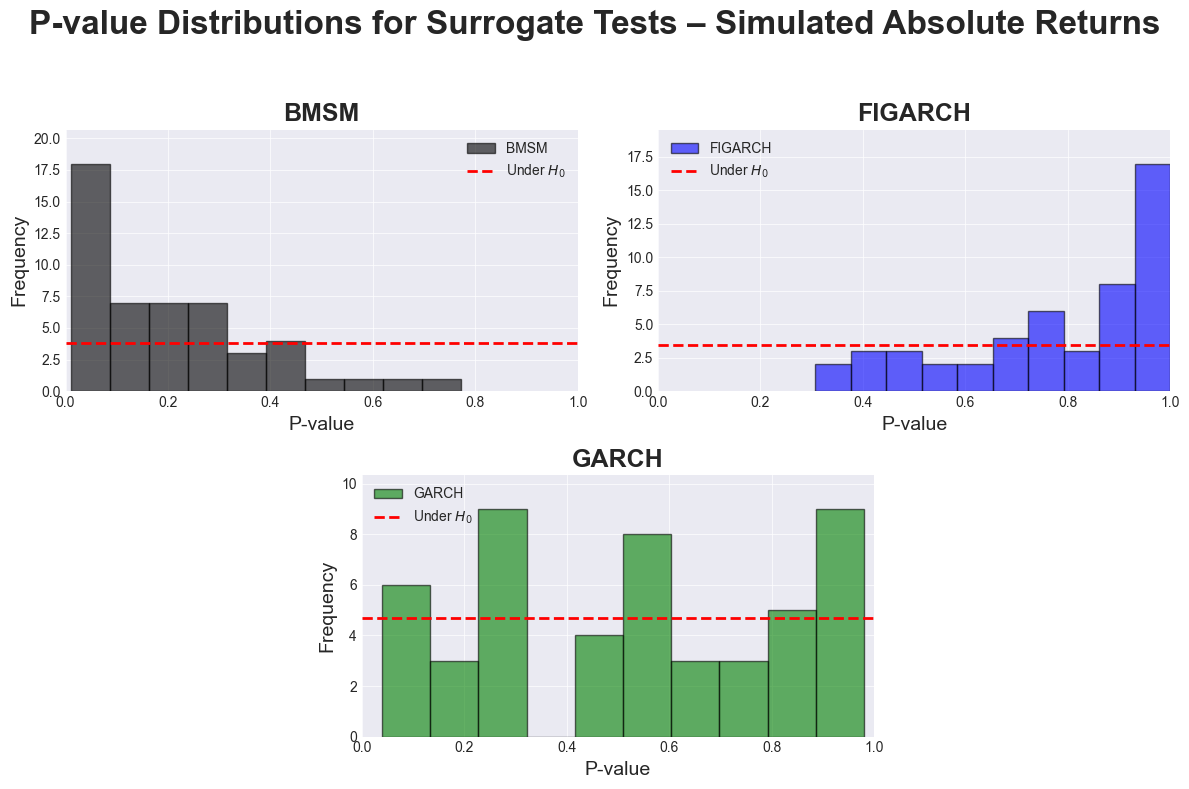

In [39]:
names = ["BMSM", "FIGARCH", "GARCH"]  
types = ['Absolute Returns']

plot_p_values(names, types[0], ps)

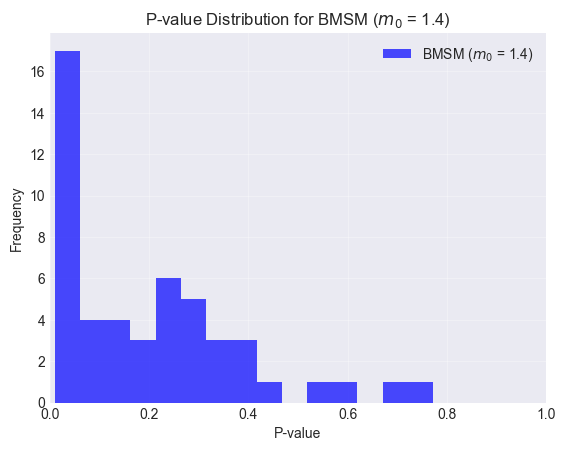

In [10]:
plt.style.use('seaborn-v0_8-dark')
plt.hist(ps_abs[0], bins=15, alpha=0.7, label=r'BMSM ($m_0$ = 1.4)', color = 'b')
plt.title(fr'P-value Distribution for BMSM ($m_0$ = 1.4)')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 1)
plt.grid(alpha = 0.3)

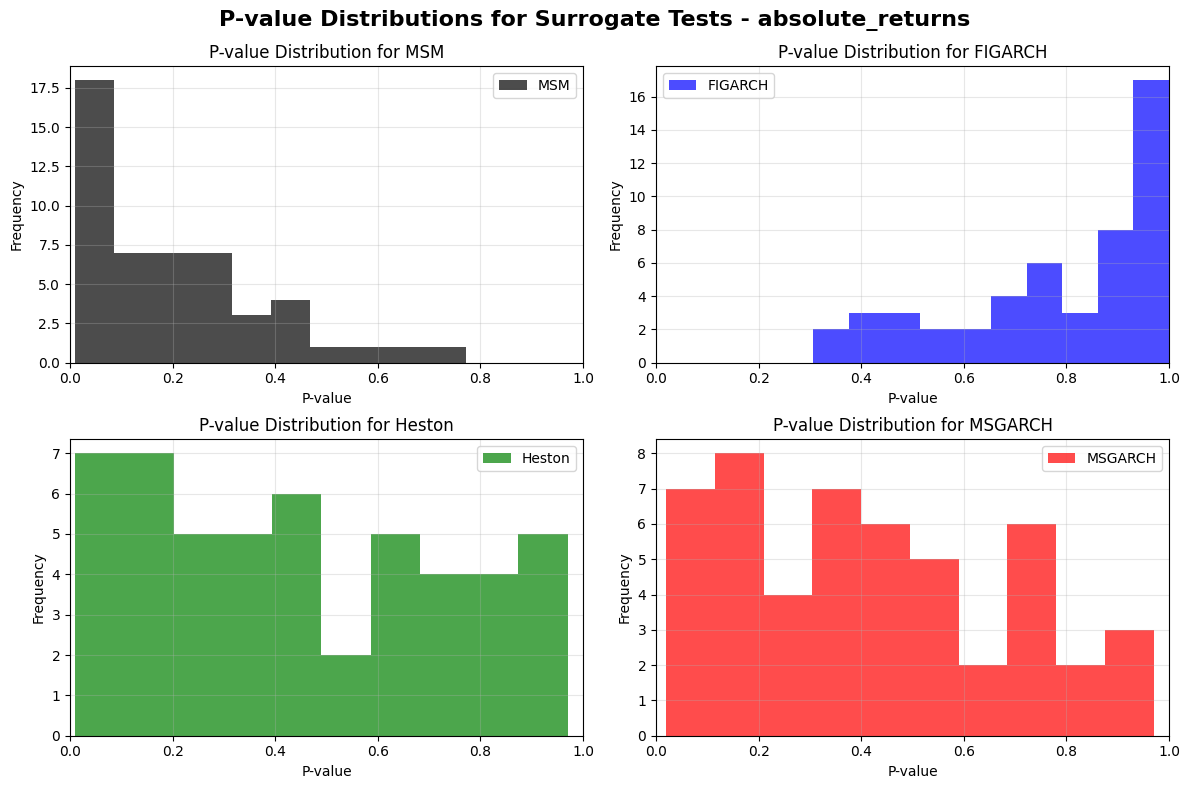

In [58]:
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

ps_abs = np.load("surrogate_tests_absolute_returns.npz")['p_values']
plot_p_values(names, types[2], ps_abs)

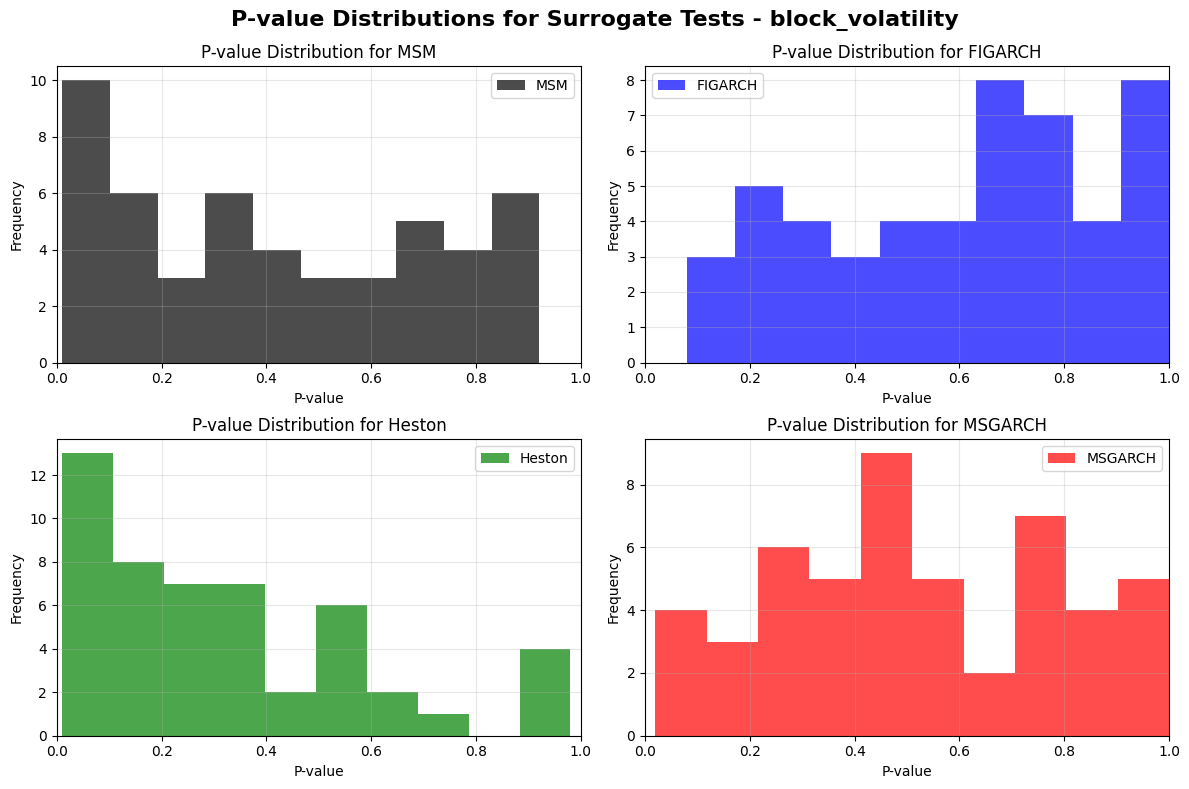

In [59]:
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

ps_block = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_tests_block_vol.npz")['p_values']
plot_p_values(names, types[3], ps_block)

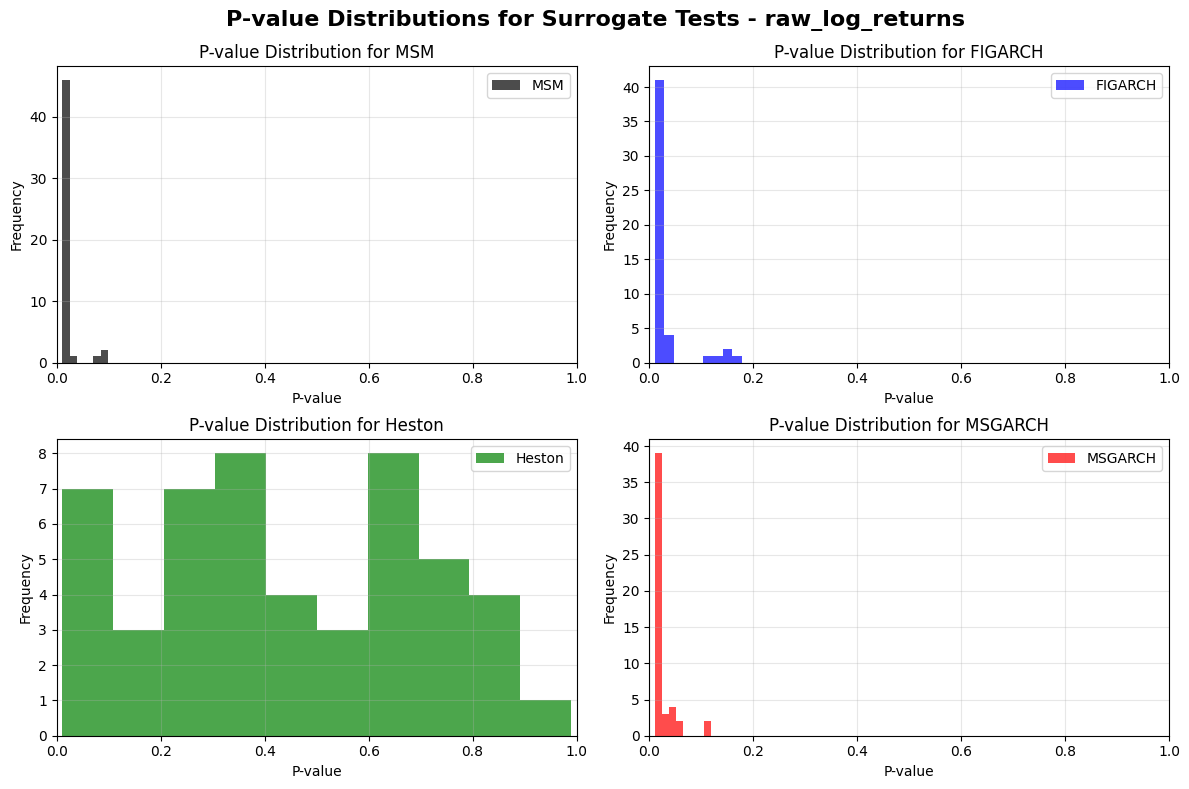

In [60]:
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

ps_raw = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_tests_raw_log_r.npz")['p_values']
plot_p_values(names, types[0], ps_raw)

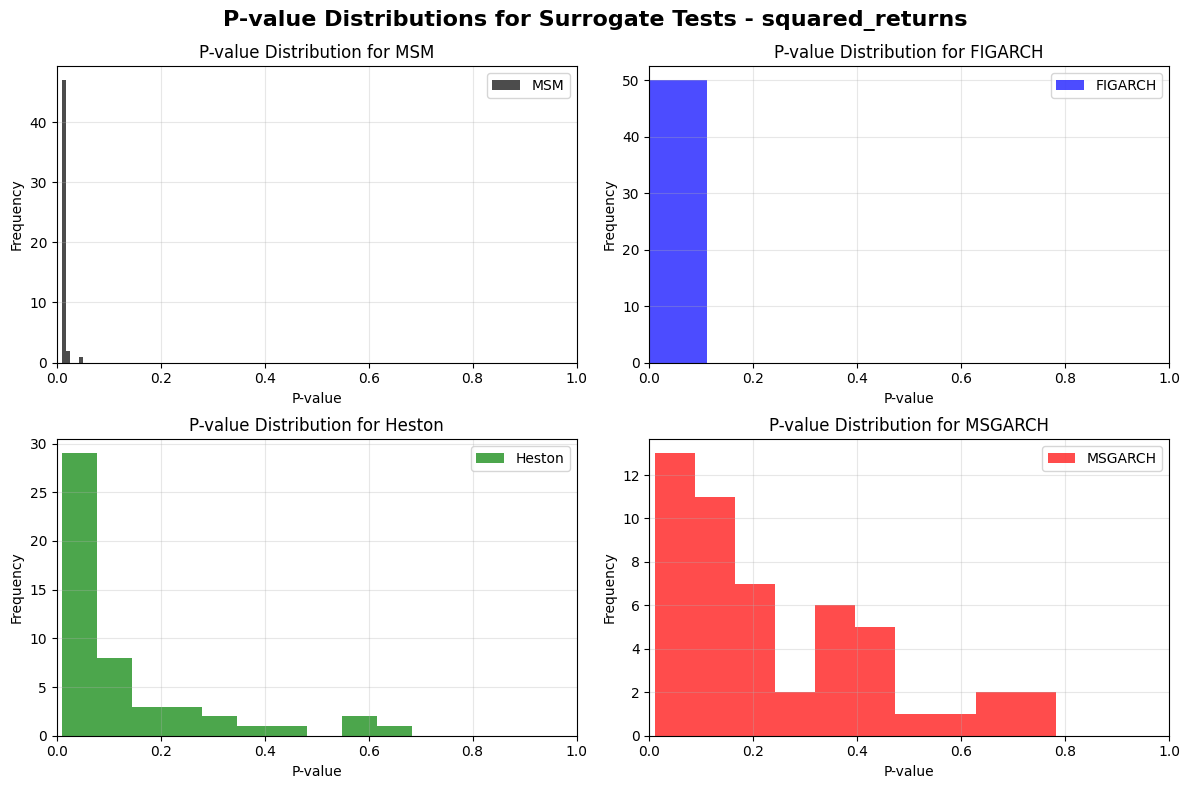

In [61]:
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

ps_block = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_tests_squared_r.npz")['p_values']
plot_p_values(names, types[1], ps_block)

# Combined prob test

Find a way to combine all 50 ps into one global p and use Holm-Bonferroni correction in the interpretation.Motivated by multiple weak evidences supporting a hypothesis are combined for strong evidence for it. 

In [148]:
def combined_p_value_analysis(ps, model_names, sig_level = 0.05, prob_test = 'stouffer'):

    global_ps = {}

    for i, name in enumerate(model_names):
        curr_global_p = combine_pvalues(ps[i], method=prob_test)[1]
        global_ps[name] = curr_global_p

    global_ps = dict(sorted(global_ps.items(), key=lambda item: item[1]))

    m = len(model_names)

    holm_bonferroni_threshold = {}

    for i, name in enumerate(global_ps.keys()):
        holm_bonferroni_threshold[name] = sig_level / (m - i)

    return global_ps, holm_bonferroni_threshold

In [152]:
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
global_ps_abs, threshs_abs = combined_p_value_analysis(ps_abs, names)

print("Combined p-values for absolute returns:")
print(global_ps_abs)
print("Holm-Bonferroni thresholds for absolute returns:")
print(threshs_abs)

Combined p-values for absolute returns:
{'MSM': np.float64(1.727871841962259e-14), 'MSGARCH': np.float64(0.02509203413583638), 'Heston': np.float64(0.09186538393402033), 'FIGARCH': np.float64(1.0)}
Holm-Bonferroni thresholds for absolute returns:
{'MSM': 0.0125, 'MSGARCH': 0.016666666666666666, 'Heston': 0.025, 'FIGARCH': 0.05}


In [154]:
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
global_ps_raw_r, threshs_raw_r = combined_p_value_analysis(ps_raw, names)

print("Combined p-values for raw returns:")
print(global_ps_raw_r)
print("Holm-Bonferroni thresholds for raw returns:")
print(threshs_raw_r)

Combined p-values for raw returns:
{'MSM': np.float64(1.976480041658907e-57), 'MSGARCH': np.float64(7.317226369284651e-53), 'FIGARCH': np.float64(1.8541068911246974e-52), 'Heston': np.float64(0.0592994921918051)}
Holm-Bonferroni thresholds for raw returns:
{'MSM': 0.0125, 'MSGARCH': 0.016666666666666666, 'FIGARCH': 0.025, 'Heston': 0.05}


# How much smaller are the widths of the surrogates? Do for raw log r and absolute

We find mean width per path for all 100 surrogates then do the familiar box plot of widths. 

In [156]:
def get_mean_widths_of_surrogates(alphas, model_names, n_paths = 50):
    
    mean_widths = []

    for i in range(len(model_names)):

        model_mean_widths = []
        model_alphas = alphas[i]

        for j in range(n_paths):
            path_alphs = model_alphas[j]
            widths = np.max(path_alphs, axis=1) - np.min(path_alphs, axis=1)
            model_mean_widths.append(np.mean(widths))

        mean_widths.append(model_mean_widths)

    return mean_widths

def get_widths_of_originals(type):

    data_msm = np.load("all_paths_msm.npz")['r']
    data_figarch = np.load("all_paths_figarch.npz")['r']
    data_heston= np.load("all_paths_heston_jumps.npz")['r']
    data_msgarch = np.load("all_paths_msgarch.npz")['r']
    datas = [data_msm, data_figarch, data_heston, data_msgarch]
    names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  

    analyser = MFDFA_Analysis_Simulation(
            datas=datas,
            burn_in=500,
            s_min=10,
            q_min=-50,
            q_max=50,
            m=1,
            steps=10,
            type=type,
            models=names, 
            block=None, 
            plots=True, 
            shuffle=False, 
            compare_to_shuffle_ind=False, 
            n_surrogates=100,
            accuracy_surrogates=5.0,  # defalt
            prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
        )

    _, alphas, _, _, _, _ = analyser.do_analysis_selected_paths()

    widths = []
    for i in range(len(names)):
        model_alphas = alphas[i]

        model_widths = np.max(model_alphas, axis=1) - np.min(model_alphas, axis=1)

        widths.append(model_widths)

    return widths

def plot_box_plots_of_widths(og_widths, surr_widths, model_names, type):
    
    plt.figure(figsize=(8, 6))

    positions_shuffled = np.arange(1, len(model_names)*2, 2) - 0.2
    positions_normal = np.arange(1, len(model_names)*2, 2) + 0.2

    bp1 = plt.boxplot(surr_widths, positions=positions_shuffled, widths=0.3, 
                    patch_artist=True, boxprops=dict(facecolor='lightcoral', alpha=0.7))
    bp2 = plt.boxplot(og_widths, positions=positions_normal, widths=0.3, 
                    patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7))

    plt.xticks(np.arange(1, len(model_names)*2, 2), model_names)
    plt.ylabel('Spectrum Width', fontsize=12)
    plt.title(f'Spectrum Widths of Surrogates (mean) vs Original Data - {type}', fontsize=14, fontweight='bold')
    plt.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Surrogates', 'Normal'], loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'/Users/alexvillamartin/Documents/MSc Diss/plots_new/surrogate_box_plots_{type}.png')
    plt.tight_layout()
    plt.show()

def run_all_box_plots(alphas_surr, type, model_names):
    
    og_widths = get_widths_of_originals(type)
    surr_widths = get_mean_widths_of_surrogates(alphas_surr, model_names)

    plot_box_plots_of_widths(og_widths, surr_widths, model_names, type)

Processing model MSM, path 1/50
Processing model MSM, path 5/50
Processing model MSM, path 9/50
Processing model MSM, path 13/50
Processing model MSM, path 17/50
Processing model MSM, path 21/50
Processing model MSM, path 25/50
Processing model MSM, path 29/50
Processing model MSM, path 33/50
Processing model MSM, path 37/50
Processing model MSM, path 41/50
Processing model MSM, path 45/50
Processing model MSM, path 49/50
Processing model FIGARCH, path 1/50
Processing model FIGARCH, path 5/50
Processing model FIGARCH, path 9/50
Processing model FIGARCH, path 13/50
Processing model FIGARCH, path 17/50
Processing model FIGARCH, path 21/50
Processing model FIGARCH, path 25/50
Processing model FIGARCH, path 29/50
Processing model FIGARCH, path 33/50
Processing model FIGARCH, path 37/50
Processing model FIGARCH, path 41/50
Processing model FIGARCH, path 45/50
Processing model FIGARCH, path 49/50
Processing model Heston, path 1/50
Processing model Heston, path 5/50
Processing model Heston, p

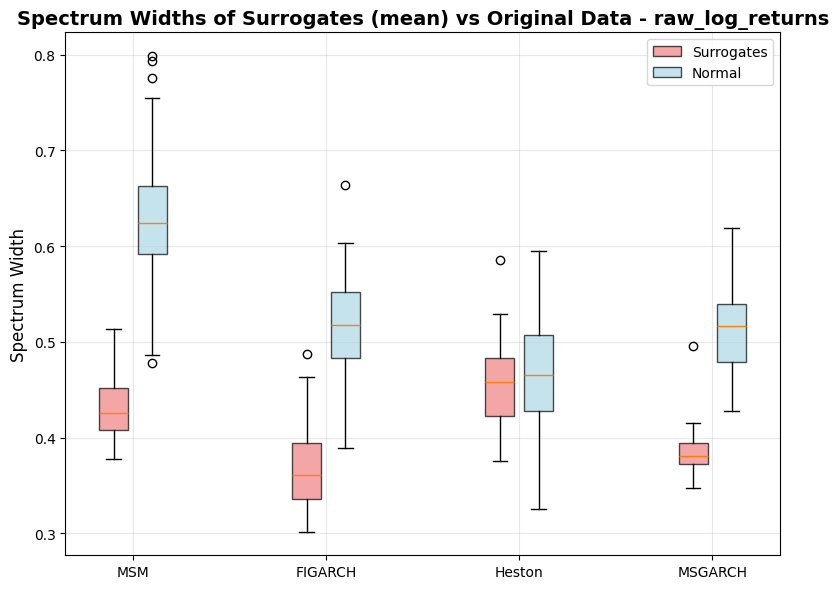

In [104]:
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
alphas_r = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_MF_raw_log_r.npz")['alphas']

run_all_box_plots(alphas_r, types[0], names)

Processing model MSM, path 1/50
Processing model MSM, path 5/50
Processing model MSM, path 9/50
Processing model MSM, path 13/50
Processing model MSM, path 17/50
Processing model MSM, path 21/50
Processing model MSM, path 25/50
Processing model MSM, path 29/50
Processing model MSM, path 33/50
Processing model MSM, path 37/50
Processing model MSM, path 41/50
Processing model MSM, path 45/50
Processing model MSM, path 49/50
Processing model FIGARCH, path 1/50
Processing model FIGARCH, path 5/50
Processing model FIGARCH, path 9/50
Processing model FIGARCH, path 13/50
Processing model FIGARCH, path 17/50
Processing model FIGARCH, path 21/50
Processing model FIGARCH, path 25/50
Processing model FIGARCH, path 29/50
Processing model FIGARCH, path 33/50
Processing model FIGARCH, path 37/50
Processing model FIGARCH, path 41/50
Processing model FIGARCH, path 45/50
Processing model FIGARCH, path 49/50
Processing model Heston, path 1/50
Processing model Heston, path 5/50
Processing model Heston, p

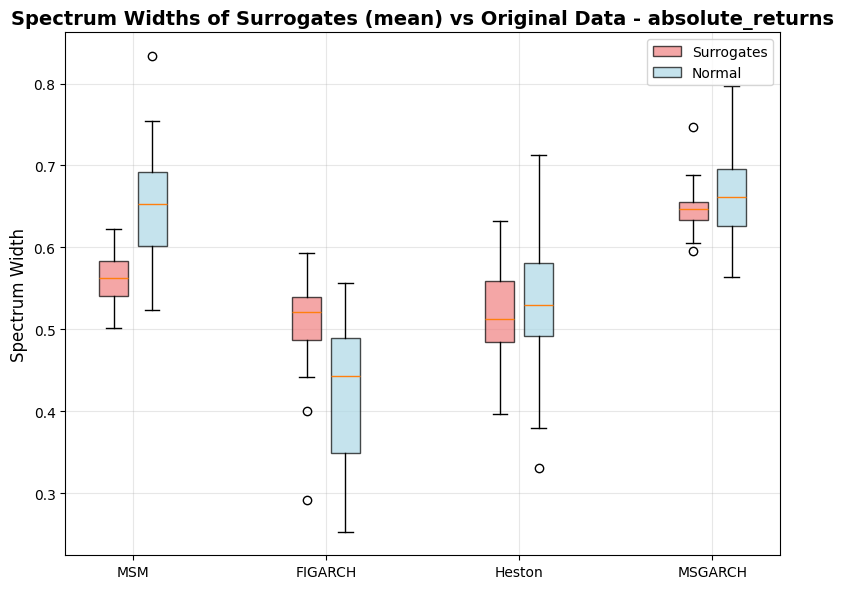

In [105]:
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
alphas_abs_r = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_MF_absolute_returns.npz")['alphas']

run_all_box_plots(alphas_abs_r, types[2], names)

### understand figarch's increase

In [168]:
def get_values_of_originals(type):

    data_msm = np.load("all_paths_msm.npz")['r']
    data_figarch = np.load("all_paths_figarch.npz")['r']
    data_heston= np.load("all_paths_heston_jumps.npz")['r']
    data_msgarch = np.load("all_paths_msgarch.npz")['r']
    datas = [data_msm, data_figarch, data_heston, data_msgarch]
    names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  

    analyser = MFDFA_Analysis_Simulation(
            datas=datas,
            burn_in=500,
            s_min=10,
            q_min=-50,
            q_max=50,
            m=1,
            steps=10,
            type=type,
            models=names, 
            block=None, 
            plots=True, 
            shuffle=False, 
            compare_to_shuffle_ind=False, 
            n_surrogates=100,
            accuracy_surrogates=5.0,  # defalt
            prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
        )

    _, alphas, f_alphas, _, _, _ = analyser.do_analysis_selected_paths()

    return alphas, f_alphas
    

In [169]:
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
alphas_abs_r_surr = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_MF_absolute_returns.npz")['alphas'][1] # get figarch ones
f_alphas_abs_r_surr = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_MF_absolute_returns.npz")['f_alphas'][1]

alphas_abs_og, f_alphas_abs_og = get_values_of_originals(types[2])

Processing model MSM, path 1/50
Processing model MSM, path 5/50
Processing model MSM, path 9/50
Processing model MSM, path 13/50
Processing model MSM, path 17/50
Processing model MSM, path 21/50
Processing model MSM, path 25/50
Processing model MSM, path 29/50
Processing model MSM, path 33/50
Processing model MSM, path 37/50
Processing model MSM, path 41/50
Processing model MSM, path 45/50
Processing model MSM, path 49/50
Processing model FIGARCH, path 1/50
Processing model FIGARCH, path 5/50
Processing model FIGARCH, path 9/50
Processing model FIGARCH, path 13/50
Processing model FIGARCH, path 17/50
Processing model FIGARCH, path 21/50
Processing model FIGARCH, path 25/50
Processing model FIGARCH, path 29/50
Processing model FIGARCH, path 33/50
Processing model FIGARCH, path 37/50
Processing model FIGARCH, path 41/50
Processing model FIGARCH, path 45/50
Processing model FIGARCH, path 49/50
Processing model Heston, path 1/50
Processing model Heston, path 5/50
Processing model Heston, p

Average surrogates per path then average the paths.

In [193]:
avg_alphas_surr_per_path = []
avg_f_alphas_surr_per_path = []

for i in range(len(alphas_abs_r_surr)):
    path_alphas = alphas_abs_r_surr[i]
    path_f_alphas = f_alphas_abs_r_surr[i]
    
    avg_path_alphas = np.mean(path_alphas, axis=0)
    avg_path_f_alphas = np.mean(path_f_alphas, axis=0)
    
    avg_alphas_surr_per_path.append(avg_path_alphas)
    avg_f_alphas_surr_per_path.append(avg_path_f_alphas)

avg_alphas_surr = np.mean(avg_alphas_surr_per_path, axis=0)
avg_f_alphas_surr = np.mean(avg_f_alphas_surr_per_path, axis=0)

avg_alphas_og = np.mean(alphas_abs_og[1], axis=0)
avg_f_alphas_og = np.mean(f_alphas_abs_og[1], axis=0)

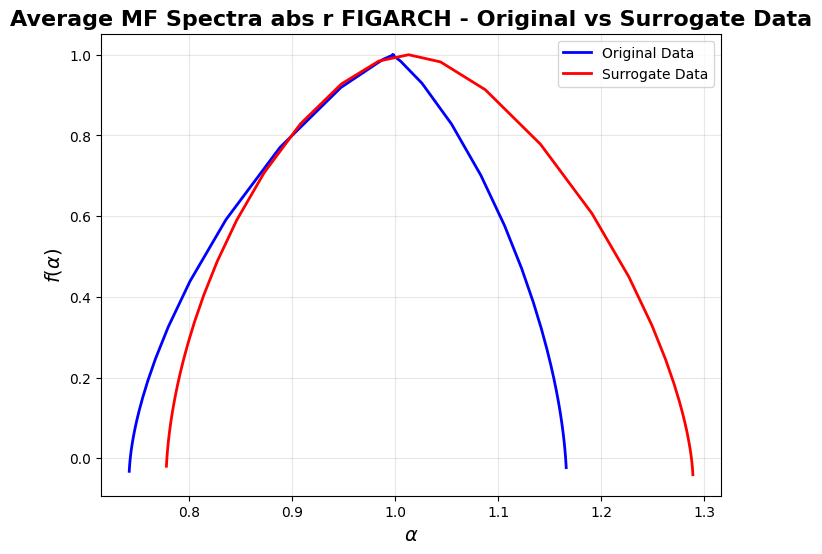

In [200]:
plt.figure(figsize=(8, 6))
plt.plot(avg_alphas_og, avg_f_alphas_og, label='Original Data', color='blue', linewidth=2)
plt.plot(avg_alphas_surr, avg_f_alphas_surr, label='Surrogate Data', color='red', linewidth=2)
plt.xlabel(r'$\alpha$', fontsize=14)
plt.ylabel(r'$f(\alpha)$', fontsize=14)
plt.title('Average MF Spectra abs r FIGARCH - Original vs Surrogate Data', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Define non linear correlations: when q != 2 since q=2 is the covariance which is porportional to ACF and hence power spectrum which is exactly what is supposed to be preserved in IAAFT.

What we know: removing the nonlinear correlations / dependence seen in higher order moments produces a larger width. 

We could conlude that FIGARCH was dominated by the linear dependence + fat tails in regard to multifractality and the nonlinear correlations if anything just smoothes these effects out > reinforces fact that FIGARCH does not have intrinsic multifractality?

In [201]:
hursts_surr = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/surrogate_MF_absolute_returns.npz")['hursts'][1]

In [203]:
avg_hursts_surr_path = []

for i in range(len(hursts_surr)):
    path_hursts = hursts_surr[i]
    avg_path_hursts = np.mean(path_hursts,axis = 0)
    avg_hursts_surr_path.append(avg_path_hursts)

mean_hursts_surr = np.mean(avg_hursts_surr_path, axis=0)

Text(0.5, 1.0, 'H(q) for Surrogate Data - Absolute Returns')

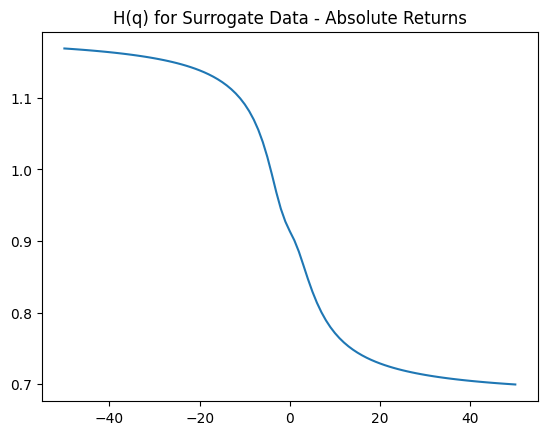

In [206]:
qs = np.arange(-50, 51, 1)
plt.plot(qs, mean_hursts_surr)
plt.title("H(q) for Surrogate Data - Absolute Returns")

# Empirical p-values

In [207]:
ps_emp = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/empirical_surrogate_tests_raw_log_r.npz")['p_values']

In [215]:
print("P-values for empirical surrogate tests:")
print("EURUSD D:", ps_emp[0])
print("USDSGD D:", ps_emp[1])
print("EURUSD S5:", ps_emp[2])
print("USDSGD S5:", ps_emp[3])

a = 0.01
print(f"Holm-Bonferroni correction for {a}:")
print("USDSGD S5", a / 4)
print("EURUSD S5", a / (4-1))
print("USDSGD D", a / (4-2))
print("EURUSD D", a / (4-3))

P-values for empirical surrogate tests:
EURUSD D: 0.6553446553446554
USDSGD D: 0.008991008991008992
EURUSD S5: 0.000999000999000999
USDSGD S5: 0.000999000999000999
Holm-Bonferroni correction for 0.01:
USDSGD S5 0.0025
EURUSD S5 0.0033333333333333335
USDSGD D 0.005
EURUSD D 0.01
